In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sunidhigautam26","key":"df9c2dd0e0f5995bb0a2fd692c71ec16"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
import os
import random
import shutil
import numpy as np
import torch
import timm
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import json

from sklearn.metrics import classification_report
from tqdm import tqdm
from collections import Counter
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.metrics import classification_report
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
RAW_DATASETS_DIR = "/content/raw_teacher_datasets"
os.makedirs(RAW_DATASETS_DIR, exist_ok=True)

print("Raw datasets will be stored in:", RAW_DATASETS_DIR)

Raw datasets will be stored in: /content/raw_teacher_datasets


**Dataset Downloads For Teacher Model**

In [6]:
print("Downloading Dataset 1: Tomato Village (GitHub)")

!git clone https://github.com/mamta-joshi-gehlot/Tomato-Village.git /content/tmp_tomato_village

shutil.move(
    "/content/tmp_tomato_village",
    os.path.join(RAW_DATASETS_DIR, "dataset_1_tomato_village")
)

print("Dataset 1 ready\n")

Cloning into '/content/tmp_tomato_village'...
remote: Enumerating objects: 45041, done.
remote: Total 45041 (delta 0), reused 0 (delta 0), pack-reused 45041 (from 1)
Receiving objects: 100% (45041/45041), 3.15 GiB | 46.77 MiB/s, done.
Resolving deltas: 100% (14380/14380), done.
Updating files: 100% (53289/53289), done.
Dataset 1 ready



In [7]:
import zipfile

print("Downloading Dataset 2: Tomato Leaf (Kaggle)")

!kaggle datasets download -d kaustubhb999/tomatoleaf -p /content

zip_path = "/content/tomatoleaf.zip"
extract_path = "/content/tmp_tomatoleaf"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

shutil.move(
    extract_path,
    os.path.join(RAW_DATASETS_DIR, "dataset_2_tomatoleaf")
)

print("Dataset 2 ready\n")

Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
 65% 116M/179M [00:00<00:00, 1.22GB/s]
100% 179M/179M [00:00<00:00, 803MB/s] 
Dataset 2 ready



In [8]:
print("Downloading Dataset 3: Tomato (Kaggle - Ashish Motwani)")

!kaggle datasets download -d ashishmotwani/tomato -p /content

zip_path = "/content/tomato.zip"
extract_path = "/content/tmp_tomato_3"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

shutil.move(
    extract_path,
    os.path.join(RAW_DATASETS_DIR, "dataset_3_tomato")
)

print("Dataset 3 ready\n")

Dataset URL: https://www.kaggle.com/datasets/ashishmotwani/tomato
License(s): copyright-authors
 99% 1.36G/1.37G [00:10<00:00, 67.1MB/s]
100% 1.37G/1.37G [00:10<00:00, 145MB/s] 
Dataset 3 ready



In [9]:
print("Downloading Dataset 4: Tomato Diseases (Kaggle)")

!kaggle datasets download -d luisolazo/tomato-diseases -p /content

zip_path = "/content/tomato-diseases.zip"
extract_path = "/content/tmp_tomato_diseases"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

shutil.move(
    extract_path,
    os.path.join(RAW_DATASETS_DIR, "dataset_4_tomato_diseases")
)

print("Dataset 4 ready\n")

Dataset URL: https://www.kaggle.com/datasets/luisolazo/tomato-diseases
License(s): CC0-1.0
 89% 365M/411M [00:00<00:00, 448MB/s]
100% 411M/411M [00:00<00:00, 469MB/s]
Dataset 4 ready



**Verify Downloads**

In [10]:
print("\nFinal raw datasets available:\n")

for d in sorted(os.listdir(RAW_DATASETS_DIR)):
    print("•", d)


Final raw datasets available:

• dataset_1_tomato_village
• dataset_2_tomatoleaf
• dataset_3_tomato
• dataset_4_tomato_diseases


**Canonical Class Map**

In [11]:
CLASS_MAP = {
    # Early blight
    "early_blight": "early_blight",
    "Early_blight": "early_blight",
    "Early Blight": "early_blight",
    "tomato___early_blight": "early_blight",
    "tomato__early blight": "early_blight",
    "EARLY-BLIGHT": "early_blight",


    # Late blight
    "late_blight": "late_blight",
    "Late_blight": "late_blight",
    "Late Blight": "late_blight",
    "tomato___late_blight": "late_blight",
    "tomato__late blight": "late_blight",


    # Bacterial spot
    "bacterial_spot": "bacterial_spot",
    "Bacterial Spot": "bacterial_spot",
    "Tomato___Bacterial_spot": "bacterial_spot",
    "Tomato_bacterial_spot": "bacterial_spot",


    # Leaf mold
    "leaf_mold": "leaf_mold",
    "Leaf Mold": "leaf_mold",
    "Leaf_Mold": "leaf_mold",
    "tomato___Leaf_Mold": "leaf_mold",


    # Healthy
    "healthy": "healthy",
    "Healthy": "healthy",
    "Tomato___healthy": "healthy",


    # Target spot
    "target_spot": "target_spot",
    "Target Spot": "target_spot",
    "Target_Spot": "target_spot",
    "target_spot___": "target_spot",
    "tomato___Target_Spot": "target_spot",


    # Powdery Mildew
    "powdery_mildew": "powdery_mildew",
    "Powdery Mildew": "powdery_mildew",
    "Powdery_mildew": "powdery_mildew",
    "Powdery_Mildew": "powdery_mildew",


    # Septoria Leaf Spot
    "septoria_leaf_spot": "septoria_leaf_spot",
    "Septoria Leaf Spot": "septoria_leaf_spot",
    "Septorialeafspot": "septoria_leaf_spot",
    "tomato___Septoria_leaf_spot": "septoria_leaf_spot",


    # Mosaic virus
    "mosaic_virus": "mosaic_virus",
    "Tomato_mosaic_virus": "mosaic_virus",
    "tomato_mosaic_virus": "mosaic_virus",
    "Tomato mosaic virus": "mosaic_virus",
    "tomato___Tomato_mosaic_virus": "mosaic_virus",


    # Spider mites (Two-spotted)
    "spider_mites_two_spotted_spider_mite": "spider_mites",
    "Spider Mites Two-spotted spider_mite": "spider_mites",
    "Spider_mites": "spider_mites",
    "spider_mites": "spider_mites",
    "twospotted_spider_mite": "spider_mites",
    "Tomato___Spider_mites Two-spotted_spider_mite": "spider_mites",


    # Yellow Leaf Curl Virus
    "yellow_leaf_curl_virus": "yellow_leaf_curl_virus",
    "TomatoYellowLeafCurlVirus": "yellow_leaf_curl_virus",
    "Tomato_Yellow_Leaf_Curl_Virus": "yellow_leaf_curl_virus",
    "Yellow Leaf Curl Virus": "yellow_leaf_curl_virus",
    "tomato___Tomato_Yellow_Leaf_Curl_Virus": "yellow_leaf_curl_virus",


    # Leaf Miner
    "leaf_miner": "leaf_miner",
    "Leaf Miner": "leaf_miner",
    "leaf miner": "leaf_miner",


    # Nitrogen deficiency
    "nitrogen_deficiency": "nitrogen_deficiency",
    "Nitrogen Deficiency": "nitrogen_deficiency",


    # Potassium deficiency
    "potassium_deficiency": "potassium_deficiency",
    "Pottassium Deficiency": "potassium_deficiency",
    "Potassium Deficiency": "potassium_deficiency",


    # Magnesium deficiency
    "magnesium_deficiency": "magnesium_deficiency",
    "Magnesium Deficiency": "magnesium_deficiency",


    # Spotted Wilt Virus
    "spotted_wilt_virus": "spotted_wilt_virus",
    "Spotted Wilt Virus": "spotted_wilt_virus",
    "Spotted_Wilt_Virus": "spotted_wilt_virus",
    "Spotted wilt virus": "spotted_wilt_virus",
}

In [12]:
RAW_DATASETS_DIR = "/content/raw_teacher_datasets"
TEACHER_DATASET_DIR = "/content/teacher_dataset"

os.makedirs(TEACHER_DATASET_DIR, exist_ok=True)

In [13]:
IGNORE_FOLDERS = {
    "train", "val", "test",
    "images", "image", "imgs"
}

**Normalize Class Names**

In [14]:
def normalize_class_name(raw):
    raw = raw.strip().lower()

    # Ignore structural folders
    if raw in IGNORE_FOLDERS:
        return None

    # Remove PlantVillage prefix
    if raw.startswith("tomato___"):
        raw = raw.replace("tomato___", "")

    # Cleanup
    raw = raw.replace("-", "_")
    raw = raw.replace(" ", "_")
    raw = raw.replace("__", "_")

    # ---- Canonical merges ----

    if "spider" in raw or "mite" in raw:
        return "spider_mites"

    if "yellow" in raw and "curl" in raw:
        return "yellow_leaf_curl_virus"

    if "mosaic" in raw:
        return "mosaic_virus"

    if "septoria" in raw:
        return "septoria_leaf_spot"

    if "early" in raw and "blight" in raw:
        return "early_blight"

    if "late" in raw and "blight" in raw:
        return "late_blight"

    if "target" in raw:
        return "target_spot"

    if "leaf" in raw and "mold" in raw:
        return "leaf_mold"

    # Nutrient deficiencies
    if "nitrogen" in raw:
        return "nitrogen_deficiency"

    if "pottassium" in raw or "potassium" in raw:
        return "potassium_deficiency"

    if "magnesium" in raw:
        return "magnesium_deficiency"

    # Healthy
    if raw == "healthy":
        return "healthy"

    return raw

In [15]:
TEACHER_DATASET_DIR = "/content/teacher_dataset"

if os.path.exists(TEACHER_DATASET_DIR):
    shutil.rmtree(TEACHER_DATASET_DIR)

os.makedirs(TEACHER_DATASET_DIR)

**Merge & Normalise Datasets**

In [16]:
IMG_EXTS = (".jpg", ".jpeg", ".png")

class_counter = {}
total_images = 0

for dataset in sorted(os.listdir(RAW_DATASETS_DIR)):
    dataset_path = os.path.join(RAW_DATASETS_DIR, dataset)
    print(f"\nProcessing {dataset}")

    for root, _, files in os.walk(dataset_path):
        imgs = [f for f in files if f.lower().endswith(IMG_EXTS)]
        if not imgs:
            continue

        raw_class = os.path.basename(root)
        norm_class = normalize_class_name(raw_class)

        if norm_class is None:
            continue

        dest_cls_dir = os.path.join(TEACHER_DATASET_DIR, norm_class)
        os.makedirs(dest_cls_dir, exist_ok=True)

        for img in imgs:
            src = os.path.join(root, img)
            dst = os.path.join(dest_cls_dir, f"{dataset}_{img}")
            shutil.copy(src, dst)

            class_counter[norm_class] = class_counter.get(norm_class, 0) + 1
            total_images += 1


Processing dataset_1_tomato_village

Processing dataset_2_tomatoleaf

Processing dataset_3_tomato

Processing dataset_4_tomato_diseases


**Teacher Dataset Summary**

In [17]:
print("\n===== CLEAN TEACHER DATASET SUMMARY =====")
print(f"Total images: {total_images}")
print(f"Total classes: {len(class_counter)}\n")

for cls, cnt in sorted(class_counter.items()):
    print(f"{cls:<30} {cnt}")


===== CLEAN TEACHER DATASET SUMMARY =====
Total images: 70252
Total classes: 16

bacterial_spot                 6781
early_blight                   7315
healthy                        7499
late_blight                    8446
leaf_miner                     1024
leaf_mold                      6497
magnesium_deficiency           936
mosaic_virus                   5478
nitrogen_deficiency            360
potassium_deficiency           72
powdery_mildew                 1256
septoria_leaf_spot             6499
spider_mites                   4958
spotted_wilt_virus             517
target_spot                    4938
yellow_leaf_curl_virus         7676


**Teacher Dataset Splitting**

In [19]:
RAW_TEACHER = "/content/teacher_dataset"
SPLIT_DIR = "/content/teacher_dataset_split"

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d)

train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

random.seed(42)
classes = sorted(os.listdir(RAW_TEACHER))

for cls in classes:
    cls_path = os.path.join(RAW_TEACHER, cls)
    if not os.path.isdir(cls_path):
        continue
    images = os.listdir(cls_path)
    random.shuffle(images)

    n = len(images)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)
    n_test  = n - n_train - n_val

    train_imgs = images[:n_train]
    val_imgs   = images[n_train:n_train+n_val]
    test_imgs  = images[n_train+n_val:]

    for folder, imgs in zip([TRAIN_DIR, VAL_DIR, TEST_DIR], [train_imgs, val_imgs, test_imgs]):
        cls_folder = os.path.join(folder, cls)
        os.makedirs(cls_folder, exist_ok=True)
        for img in imgs:
            shutil.copy(os.path.join(cls_path, img), os.path.join(cls_folder, img))

In [27]:
BATCH_SIZE = 32
NUM_EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [28]:
import shutil
import os

SRC_DIR = "/content/teacher_dataset"
DEST_DIR = "/content/drive/MyDrive/datasets/teacher_dataset"

os.makedirs(os.path.dirname(DEST_DIR), exist_ok=True)

In [21]:
shutil.copytree(SRC_DIR, DEST_DIR)

'/content/drive/MyDrive/datasets/teacher_dataset'

In [29]:
# ----------------------------
# Data Transforms
# ----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [30]:
# ----------------------------
# Datasets & DataLoaders
# ----------------------------
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_transform)

In [31]:
# ----------------------------
# Handling Class Imbalance
# ----------------------------
# Compute class frequencies
class_counts = [0]*len(train_dataset.classes)
for _, label in train_dataset.samples:
    class_counts[label] += 1

beta = 0.999
effective_num = [1 - beta**n for n in class_counts]
weights = [(1-beta)/n for n in effective_num]
weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)
weights = weights / weights.sum() * len(weights)

criterion = nn.CrossEntropyLoss(weight=weights)

# WeightedRandomSampler
MAX_CLASS_WEIGHT = 5.0
sample_weights = [min(1.0 / class_counts[label], MAX_CLASS_WEIGHT) for _, label in train_dataset.samples]
train_sampler = WeightedRandomSampler(weights=sample_weights,
                                      num_samples=len(sample_weights),
                                      replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


In [32]:
# ----------------------------
# Teacher Model
# ----------------------------
teacher_model = timm.create_model('efficientnet_b2', pretrained=True, num_classes=len(train_dataset.classes))
teacher_model = teacher_model.to(DEVICE)

optimizer = optim.Adam(teacher_model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

In [33]:
# ----------------------------
# Training Loop
# ----------------------------
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    # --- Training ---
    teacher_model.train()
    running_loss, correct, total = 0, 0, 0

    train_loader_tqdm = tqdm(train_loader, desc="Training", leave=False)
    for images, labels in train_loader_tqdm:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = teacher_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        train_loader_tqdm.set_postfix({
            "Loss": f"{running_loss/total:.4f}",
            "Acc": f"{correct/total:.4f}"
        })

    train_loss = running_loss / total
    train_acc = correct / total

    # --- Validation ---
    teacher_model.eval()
    val_running_loss, val_correct, val_total = 0, 0, 0

    val_loader_tqdm = tqdm(val_loader, desc="Validation", leave=False)
    for images, labels in val_loader_tqdm:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        with torch.no_grad():
            outputs = teacher_model(images)
            loss = criterion(outputs, labels)

        val_running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        val_correct += (preds == labels).sum().item()
        val_total += labels.size(0)

        val_loader_tqdm.set_postfix({
            "Loss": f"{val_running_loss/val_total:.4f}",
            "Acc": f"{val_correct/val_total:.4f}"
        })

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch 1/10


Train Loss: 0.2287 | Train Acc: 0.8781 | Val Loss: 0.2217 | Val Acc: 0.9324

Epoch 2/10


Train Loss: 0.0636 | Train Acc: 0.9667 | Val Loss: 0.1270 | Val Acc: 0.9601

Epoch 3/10


Train Loss: 0.0253 | Train Acc: 0.9836 | Val Loss: 0.1604 | Val Acc: 0.9588

Epoch 4/10


Train Loss: 0.0199 | Train Acc: 0.9880 | Val Loss: 0.0937 | Val Acc: 0.9757

Epoch 5/10


...

Train Loss: 0.0108 | Train Acc: 0.9928 | Val Loss: 0.0632 | Val Acc: 0.9841

Epoch 7/10


Train Loss: 0.0137 | Train Acc: 0.9912 | Val Loss: 0.0949 | Val Acc: 0.9763

Epoch 8/10


Train Loss: 0.0115 | Train Acc: 0.9927 | Val Loss: 0.0813 | Val Acc: 0.9796

Epoch 9/10


Train Loss: 0.0123 | Train Acc: 0.9930 | Val Loss: 0.0660 | Val Acc: 0.9850

Epoch 10/10


Train Loss: 0.0098 | Train Acc: 0.9941 | Val Loss: 0.0962 | Val Acc: 0.9799


In [34]:
# ----------------------------
# Save Model & History
# ----------------------------
SAVE_DIR = "/content/drive/MyDrive/teacher_model"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(teacher_model.state_dict(), f"{SAVE_DIR}/teacher_efficientnet_b2.pth")
torch.save(history, f"{SAVE_DIR}/teacher_history.pt")

with open(f"{SAVE_DIR}/teacher_classes.json", "w") as f:
    json.dump(train_dataset.classes, f)

experiment_info = {
    "dataset": "tomato-leaf-disease",
    "source": "Kaggle",
    "num_classes": len(train_dataset.classes),
    "classes": train_dataset.classes,
    "input_size": 224,
    "model": "efficientnet_b2",
    "epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "best_val_acc": max(history['val_acc'])
}

with open(f"{SAVE_DIR}/experiment.json", "w") as f:
    json.dump(experiment_info, f, indent=4)

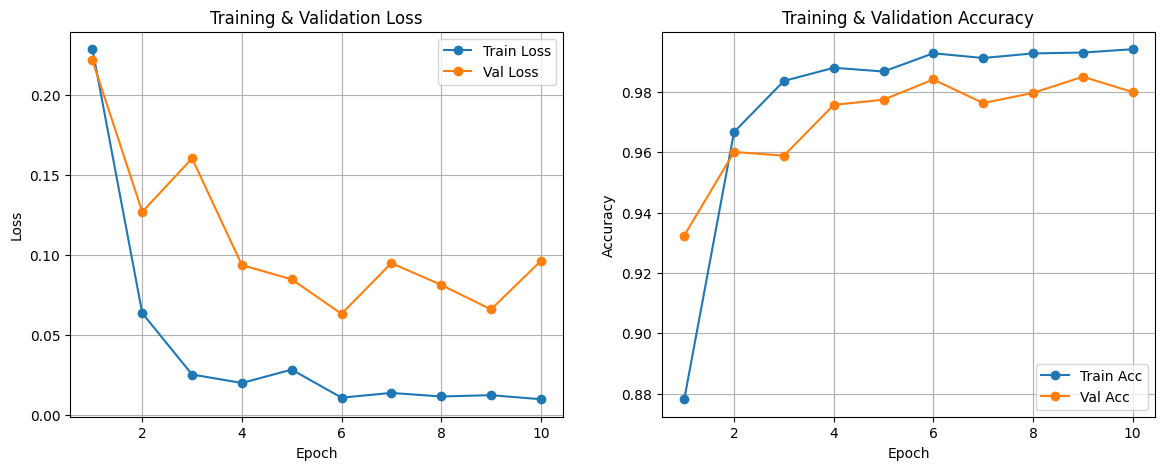

In [35]:
# ----------------------------
# Plot Training Curves
# ----------------------------
epochs = range(1, NUM_EPOCHS + 1)
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, history['train_acc'], label='Train Acc', marker='o')
plt.plot(epochs, history['val_acc'], label='Val Acc', marker='o')
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

In [36]:
# ----------------------------
# Test Evaluation
# ----------------------------
teacher_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = teacher_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = sum([p==l for p,l in zip(all_preds, all_labels)]) / len(all_labels)
print(f"Test Accuracy: {test_acc*100:.2f}%")

print("\n===== CLASSIFICATION REPORT (TEST SET) =====\n")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes, digits=4))

Test Accuracy: 98.03%

===== CLASSIFICATION REPORT (TEST SET) =====

                        precision    recall  f1-score   support

        bacterial_spot     0.9874    0.9863    0.9869       952
          early_blight     0.9769    0.9816    0.9792      1032
               healthy     0.9765    0.9802    0.9783      1059
           late_blight     0.9890    0.9700    0.9794      1201
            leaf_miner     0.9195    0.8839    0.9013       155
             leaf_mold     0.9967    0.9912    0.9939       909
  magnesium_deficiency     0.8868    1.0000    0.9400       141
          mosaic_virus     0.9803    0.9868    0.9835       756
   nitrogen_deficiency     0.8730    1.0000    0.9322        55
  potassium_deficiency     0.8462    0.9167    0.8800        12
        powdery_mildew     0.9639    0.9894    0.9765       189
    septoria_leaf_spot     0.9771    0.9857    0.9814       909
          spider_mites     1.0000    0.9971    0.9985       678
    spotted_wilt_virus     0.7564 

In [37]:
from sklearn.metrics import confusion_matrix
teacher_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = teacher_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [38]:
cm = confusion_matrix(all_labels, all_preds)

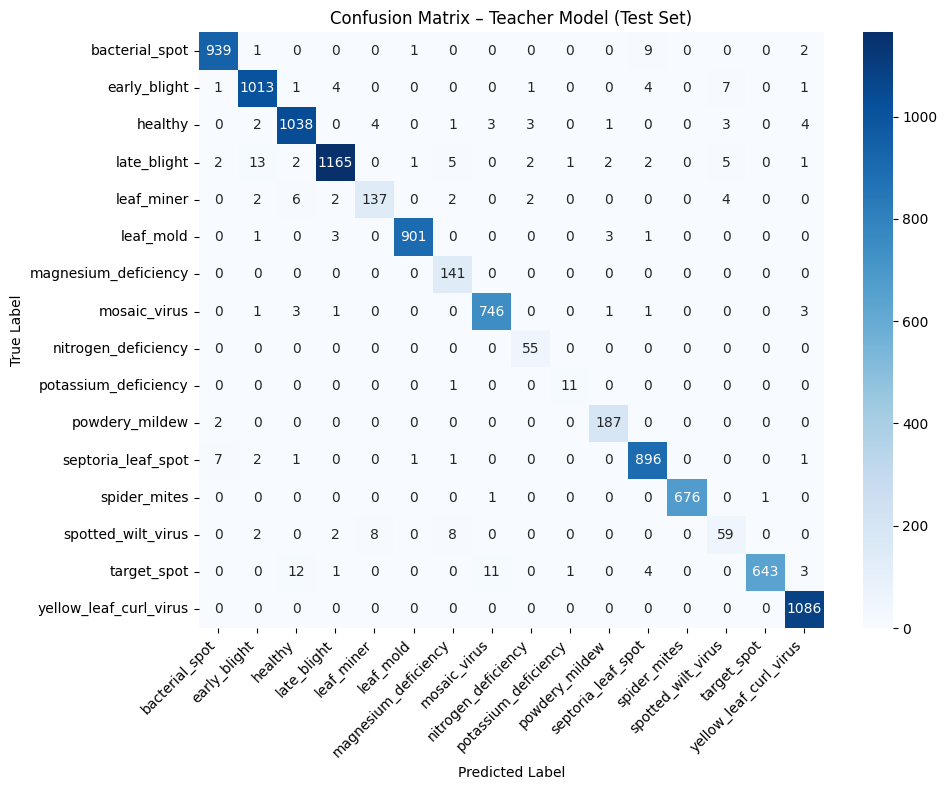

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = test_dataset.classes
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Teacher Model (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

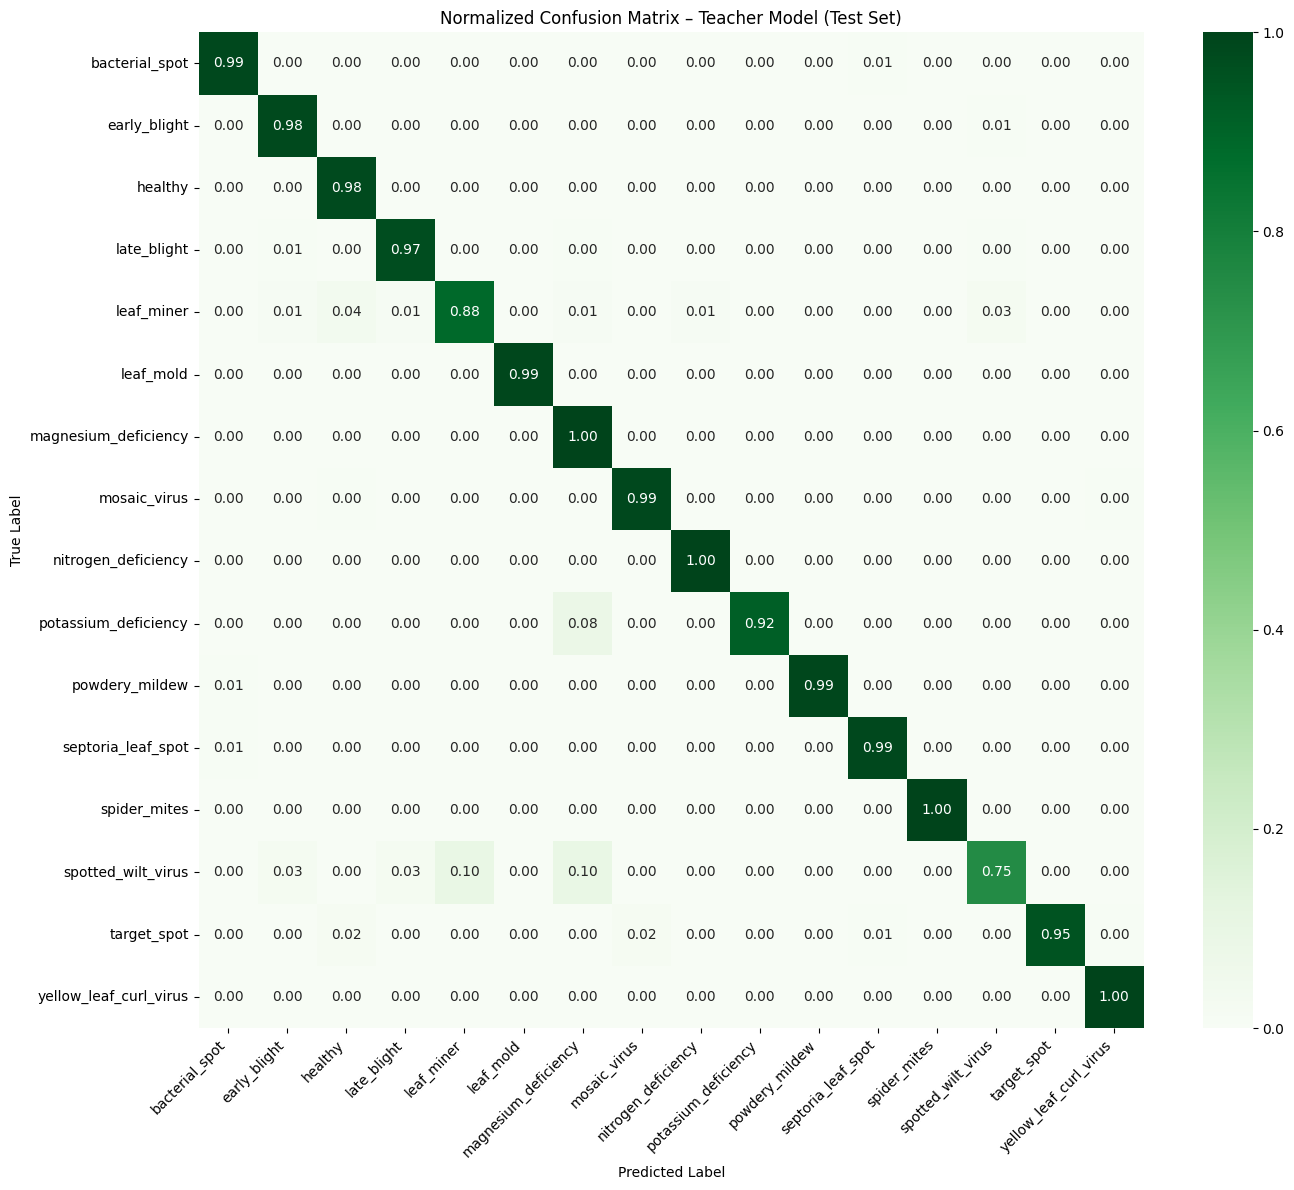

In [40]:
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix – Teacher Model (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Loading & Normalising Client Prototypes**

In [41]:
import torch
from itertools import chain

CLIENT_PROTOTYPE_PATHS = [
    "/content/client1_prototypes.pt",
    "/content/client2_prototypes.pt"
]

def normalize_class_name(name):
    return name.strip().lower().replace(" ", "_")

client_prototypes = []

for path in CLIENT_PROTOTYPE_PATHS:
    proto = torch.load(path, weights_only=False)  # {class_name: embedding}
    proto = {normalize_class_name(k): torch.tensor(v, dtype=torch.float32)
             for k, v in proto.items()}
    client_prototypes.append(proto)

print("Loaded client prototypes:", [len(p) for p in client_prototypes])

Loaded client prototypes: [4, 10]


**Aggregating Prototypes -> Global Prototypes**

In [42]:
global_classes = sorted(set(chain.from_iterable(p.keys() for p in client_prototypes)))
print("Global classes:", global_classes)

global_prototypes = {}

for cls in global_classes:
    embeddings = []
    for proto in client_prototypes:
        if cls in proto:
            embeddings.append(proto[cls].unsqueeze(0))
    global_prototypes[cls] = torch.cat(embeddings, dim=0).mean(dim=0)

print("Global prototype dimension:", next(iter(global_prototypes.values())).shape)

Global classes: ['tomato___bacterial_spot', 'tomato___early_blight', 'tomato___healthy', 'tomato___late_blight', 'tomato___leaf_mold', 'tomato___septoria_leaf_spot', 'tomato___spider_mites_two-spotted_spider_mite', 'tomato___target_spot', 'tomato___tomato_mosaic_virus', 'tomato___tomato_yellow_leaf_curl_virus']
Global prototype dimension: torch.Size([62720])


**Reloading Teacher Model (Feature Extractor)**

In [45]:
teacher_model = timm.create_model(
    "efficientnet_b2",
    pretrained=False,
    num_classes=0        # removes classifier
)

state = torch.load("/content/drive/MyDrive/teacher_model/teacher_efficientnet_b2.pth", map_location=DEVICE)
teacher_model.load_state_dict(state, strict=False)  # allow missing classifier

teacher_model.to(DEVICE)
teacher_model.eval()


EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [46]:
dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

with torch.no_grad():
    feat = teacher_model(dummy)

print("Teacher feature shape:", feat.shape)

Teacher feature shape: torch.Size([1, 1408])


**Extract Teacher Prototypes**

In [47]:
from collections import defaultdict
from tqdm import tqdm

def extract_teacher_prototypes(teacher_model, dataloader, class_to_idx):
    teacher_model.eval()
    feature_bank = defaultdict(list)

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting teacher prototypes"):
            images = images.to(device)
            labels = labels.to(device)

            features = teacher_model(images)  # [B, 1408]

            for feat, lbl in zip(features, labels):
                cls = list(class_to_idx.keys())[lbl.item()]
                feature_bank[cls].append(feat.cpu())

    prototypes = {
        cls: torch.stack(feats).mean(dim=0)
        for cls, feats in feature_bank.items()
    }

    return prototypes

**Saving the dataset split in drive**

In [54]:
import shutil

drive_path = "/content/drive/MyDrive/teacher_dataset_split/"

# This deletes the entire folder
shutil.rmtree(drive_path)

# Now copy from Colab
correct_path = "/content/teacher_dataset_split/"
shutil.copytree(correct_path, drive_path)
print("Teacher dataset replaced successfully!")

KeyboardInterrupt: 

**Running Teacher Prototype Extraction**

In [55]:
from torchvision.datasets import ImageFolder
teacher_train_dir = "/content/teacher_dataset_split/train"

teacher_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

teacher_dataset = ImageFolder(teacher_train_dir, transform=teacher_transform)
teacher_loader = DataLoader(teacher_dataset, batch_size=32, shuffle=False)

In [56]:
teacher_prototypes = extract_teacher_prototypes(
    teacher_model=teacher_model,
    dataloader=train_loader,
    class_to_idx=teacher_dataset.class_to_idx
)

# Verify
for k, v in teacher_prototypes.items():
    print(k, v.shape)
    break

Extracting teacher prototypes: 100%|██████████| 1440/1440 [02:56<00:00,  8.15it/s]


bacterial_spot torch.Size([1408])


In [57]:
print("Teacher classes extracted:")
for cls in teacher_prototypes.keys():
    print(cls, teacher_prototypes[cls].shape)

Teacher classes extracted:
bacterial_spot torch.Size([1408])
yellow_leaf_curl_virus torch.Size([1408])
spotted_wilt_virus torch.Size([1408])
leaf_miner torch.Size([1408])
target_spot torch.Size([1408])
spider_mites torch.Size([1408])
potassium_deficiency torch.Size([1408])
early_blight torch.Size([1408])
late_blight torch.Size([1408])
septoria_leaf_spot torch.Size([1408])
leaf_mold torch.Size([1408])
mosaic_virus torch.Size([1408])
nitrogen_deficiency torch.Size([1408])
magnesium_deficiency torch.Size([1408])
powdery_mildew torch.Size([1408])
healthy torch.Size([1408])


**Saving Teacher Prototypes**

In [58]:
for cls, proto in teacher_prototypes.items():
    print(cls, proto.shape)
    break

bacterial_spot torch.Size([1408])


In [60]:
torch.save(
    teacher_prototypes,
    "/content/drive/MyDrive/teacher_prototypes.pt"
)

print("Saved teacher prototypes!!")

Saved teacher prototypes!!


In [61]:
# Load the saved teacher prototypes
teacher_prototypes = torch.load("/content/drive/MyDrive/teacher_prototypes.pt")

print("Number of teacher classes:", len(teacher_prototypes))

# Check each class and the feature dimension
for cls_name, feat in teacher_prototypes.items():
    print(f"{cls_name}: {feat.shape}")

Number of teacher classes: 16
bacterial_spot: torch.Size([1408])
yellow_leaf_curl_virus: torch.Size([1408])
spotted_wilt_virus: torch.Size([1408])
leaf_miner: torch.Size([1408])
target_spot: torch.Size([1408])
spider_mites: torch.Size([1408])
potassium_deficiency: torch.Size([1408])
early_blight: torch.Size([1408])
late_blight: torch.Size([1408])
septoria_leaf_spot: torch.Size([1408])
leaf_mold: torch.Size([1408])
mosaic_virus: torch.Size([1408])
nitrogen_deficiency: torch.Size([1408])
magnesium_deficiency: torch.Size([1408])
powdery_mildew: torch.Size([1408])
healthy: torch.Size([1408])
